In [1]:
from datetime import datetime
import sys
import os
import time
# Set the current directory and utilities path
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')

# Change the working directory to the notebook's directory
os.chdir(current_dir)

# Modify the module search path to include utilities directory
sys.path.insert(0, utilities_dir)

import importlib
import analytical_solution_functions
import bem_solution_functions
import plotting_functions

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
bem_df

NameError: name 'bem_df' is not defined

In [ ]:
pinn_df

,hidden_layers,hidden_units,mean_relative_error,std_relative_error,best_relative_error,training_time_sec,std_training_time_sec,mean_eval_time_sec,std_eval_time_sec
0,1,25,1.290576,3.197195e-03,1.289510,82.668171,3.869611,0.054776,0.012666
1,1,50,0.934473,1.110223e-16,0.934473,160.795874,5.996508,0.054364,0.011954
2,1,75,0.855440,0.000000e+00,0.855440,218.293483,8.192615,0.068016,0.051700
3,2,25,0.186528,0.000000e+00,0.186528,251.916757,2.042732,0.046861,0.006627
4,2,50,0.075216,0.000000e+00,0.075216,253.984502,2.101088,0.047084,0.005809
5,2,75,0.073524,0.000000e+00,0.073524,261.500900,1.598429,0.053672,0.004874
6,3,25,0.074361,0.000000e+00,0.074361,289.872799,1.981856,0.046992,0.002940
7,3,50,0.074525,1.387779e-17,0.074525,293.166391,1.815062,0.057328,0.010662
8,3,75,0.074517,1.387779e-17,0.074517,305.630320,2.106559,0.056494,0.007189


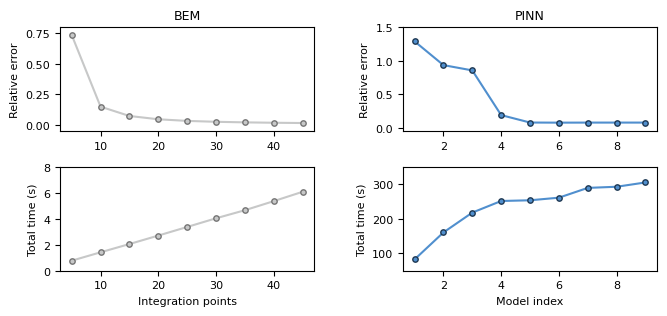

In [10]:
 

# --- Load data ---
bem_df = pd.read_csv("data/bem_accuracy_vs_n.csv")
pinn_df = pd.read_csv("data/pinn_accuracy_vs_architecture.csv")

# --- BEM ---
bem_df = bem_df.sort_values("n")

n_bem = bem_df["n"].values
e_bem = bem_df["relative_error"].values

time_bem = (
    bem_df["evaluation_time_sec"].values +
    bem_df["assembly_solution_time_sec"].values
)

# --- PINN ---
pinn_df = pinn_df.copy()
pinn_df["model_id"] = np.arange(1, len(pinn_df) + 1)

model_id = pinn_df["model_id"].values
e_pinn = pinn_df["mean_relative_error"].values

time_pinn = (
    pinn_df["training_time_sec"].values +
    pinn_df["mean_eval_time_sec"].values
)

# --- Figure (2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(6.5, 3.0))

# =========================
# TOP LEFT: BEM - Error
# =========================
axes[0, 0].plot(n_bem, e_bem, color="#c7c8c8ff", zorder=1)
axes[0, 0].scatter(n_bem, e_bem, s=15, color="#c7c8c8ff", edgecolor="#757575ff", zorder=2)
axes[0, 0].set_title("BEM", size=9)
#axes[0, 0].set_xlabel("Integration points")
axes[0, 0].set_ylim(-0.05, 0.8)
axes[0, 0].set_ylabel("Relative error")

# =========================
# TOP RIGHT: PINN - Error
# =========================
axes[0, 1].plot(model_id, e_pinn, color="#508fceff", zorder=1)
axes[0, 1].scatter(model_id, e_pinn, s=15, color="#508fceff", edgecolor="#1e3852ff", zorder=2)
axes[0, 1].set_title("PINN", size=9)
#axes[0, 1].set_xlabel("Model index")
axes[0, 1].set_ylabel("Relative error")
axes[0, 1].set_ylim(-0.05, 1.5)

# =========================
# BOTTOM LEFT: BEM - Time
# =========================
axes[1, 0].plot(n_bem, time_bem, color="#c7c8c8ff", zorder=1)
axes[1, 0].scatter(n_bem, time_bem, s=15, color="#c7c8c8ff", edgecolor="#757575ff", zorder=2)
axes[1, 0].set_xlabel("Integration points")
axes[1, 0].set_ylim(-0.0, 8)
axes[1, 0].set_ylabel("Total time (s)")

# =========================
# BOTTOM RIGHT: PINN - Time
# =========================
axes[1, 1].plot(model_id, time_pinn, color="#508fceff", zorder=1)
axes[1, 1].scatter(model_id, time_pinn, s=15, color="#508fceff", edgecolor="#1e3852ff", zorder=2)
axes[1, 1].set_ylim(50, 350)
axes[1, 1].set_xlabel("Model index")
axes[1, 1].set_ylabel("Total time (s)")

plt.tight_layout()
fig.subplots_adjust(wspace=0.35, hspace=0.35)
plt.savefig("figures/bem_pinn_convergence.pdf", dpi=300)
plt.savefig("figures/bem_pinn_convergence.svg", dpi=300)
plt.show()